In [ ]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torchvision.models import resnet18
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
from IPython.display import display

from data_utils import (
    RANDOM_STATE,
    IMAGE_SIZE,
    BATCH_SIZE,
    NUM_WORKERS,
    TARGET_COLUMNS,
    TARGET_NAMES,
    seed_everything,
    prepare_splits,
    build_transforms,
    PhotoQualityDataset,
    create_loaders,
)

In [2]:
seed_everything(RANDOM_STATE)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Пристрій:", device)

if device.type == "cuda":
    print("Відеокарта:", torch.cuda.get_device_name(0))
else:
    print("GPU не підключений.")

Пристрій: cpu
GPU не підключений.


In [3]:
DEBUG_MODE = True
NUM_EPOCHS = 7 if DEBUG_MODE else 15

BACKBONE_LEARNING_RATE = 0.00001
HEAD_LEARNING_RATE = 0.0001
WEIGHT_DECAY = 0.0001

EARLY_STOPPING_PATIENCE = 4
MIN_DELTA = 0.00001

MODEL_NAME = "ResNet18"
MODEL_PREFIX = "resnet_fine_tuning"
ARCHITECTURE = "resnet18"
TRAINING_STRATEGY = "Fine-tuning layer4"

In [4]:
print("Debug mode:", DEBUG_MODE)
print("Кількість епох:", NUM_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate для layer4:", BACKBONE_LEARNING_RATE)
print("Learning rate для fc:", HEAD_LEARNING_RATE)

Debug mode: True
Кількість епох: 7
Batch size: 16
Learning rate для layer4: 1e-05
Learning rate для fc: 0.0001


In [5]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_manifest.csv"
IMAGES_DIRECTORY = PROJECT_ROOT / "data" / "raw" / "SPAQ_small"

MODELS_DIRECTORY = PROJECT_ROOT / "artifacts" / "models"
RESULTS_DIRECTORY = PROJECT_ROOT / "artifacts" / "results"

MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIRECTORY / f"{MODEL_PREFIX}_best.pt"
HISTORY_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_history.csv"
METRICS_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_metrics.csv"
TARGET_METRICS_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_metrics_by_target.csv"
PREDICTIONS_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_predictions.csv"

FEATURE_EXTRACTION_MODEL_PATH = MODELS_DIRECTORY / "resnet_feature_extraction_best.pt"
FEATURE_METRICS_PATH = RESULTS_DIRECTORY / "resnet_feature_extraction_metrics.csv"
COMPARISON_PATH = RESULTS_DIRECTORY / "resnet_comparison.csv"

LOSS_PLOT_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_loss.png"
SCATTER_PLOT_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_scatter.png"

print("Manifest:", MANIFEST_PATH)
print("Фотографії:", IMAGES_DIRECTORY)
print("Модель:", MODEL_PATH)
print("Результати:", RESULTS_DIRECTORY)
print("Початкові ваги:", FEATURE_EXTRACTION_MODEL_PATH)

Manifest: c:\Users\Admin\Desktop\PhotoAnalyser\data\processed\dataset_manifest.csv
Фотографії: c:\Users\Admin\Desktop\PhotoAnalyser\data\raw\SPAQ_small
Модель: c:\Users\Admin\Desktop\PhotoAnalyser\artifacts\models\resnet_fine_tuning_best.pt
Результати: c:\Users\Admin\Desktop\PhotoAnalyser\artifacts\results
Початкові ваги: c:\Users\Admin\Desktop\PhotoAnalyser\artifacts\models\resnet_feature_extraction_best.pt


Підготовка даних

In [6]:
manifest = pd.read_csv(
    MANIFEST_PATH
)

print("Розмір manifest:", manifest.shape)
print("Колонки:")
print(manifest.columns.tolist())

display(manifest.head())

Розмір manifest: (11125, 12)
Колонки:
['image_name', 'overall_quality', 'brightness_quality', 'colorfulness_quality', 'contrast_quality', 'noise_quality', 'sharpness_quality', 'width', 'height', 'color_mode', 'quality_bin', 'split']


,image_name,overall_quality,brightness_quality,colorfulness_quality,contrast_quality,noise_quality,sharpness_quality,width,height,color_mode,quality_bin,split
0,02051.jpg,20.63,30.88,39.88,28.63,13.71,14.88,512,384,RGB,0,test
1,03819.jpg,70.71,67.43,68.57,74.71,74.00,66.86,384,512,RGB,7,train
2,02746.jpg,71.00,67.27,70.72,61.87,63.42,69.22,384,512,RGB,7,validation
3,06586.jpg,72.83,71.50,75.00,70.67,71.33,74.00,384,512,RGB,8,test
4,01016.jpg,38.14,64.29,63.43,52.25,28.75,25.63,512,383,RGB,3,train


In [7]:
train_dataframe, validation_dataframe, test_dataframe = prepare_splits(
    manifest=manifest,
    debug_mode=DEBUG_MODE,
    random_state=RANDOM_STATE,
)

print("Train:", len(train_dataframe))
print("Validation:", len(validation_dataframe))
print("Test:", len(test_dataframe))

Train: 3000
Validation: 600
Test: 600


In [9]:
train_transform, evaluation_transform = build_transforms(
    image_size=IMAGE_SIZE,
)

In [10]:
train_dataset = PhotoQualityDataset(
    dataframe=train_dataframe,
    images_directory=IMAGES_DIRECTORY,
    target_columns=TARGET_COLUMNS,
    transform=train_transform,
)

validation_dataset = PhotoQualityDataset(
    dataframe=validation_dataframe,
    images_directory=IMAGES_DIRECTORY,
    target_columns=TARGET_COLUMNS,
    transform=evaluation_transform,
)

test_dataset = PhotoQualityDataset(
    dataframe=test_dataframe,
    images_directory=IMAGES_DIRECTORY,
    target_columns=TARGET_COLUMNS,
    transform=evaluation_transform,
)

In [11]:
print("Train dataset:", len(train_dataset))
print(
    "Validation dataset:",
    len(validation_dataset),
)
print("Test dataset:", len(test_dataset))

Train dataset: 3000
Validation dataset: 600
Test dataset: 600


In [12]:
sample_image, sample_targets, sample_name = validation_dataset[0]

print("Фото:", sample_name)
print("Форма зображення:", sample_image.shape)
print("Оцінки:", sample_targets * 100)

Фото: 06925.jpg
Форма зображення: torch.Size([3, 224, 224])
Оцінки: tensor([53.0000, 58.8000, 50.4000, 57.8000, 44.2000, 55.6000])


In [13]:
train_loader, validation_loader, test_loader = create_loaders(
    train_dataset=train_dataset,
    validation_dataset=validation_dataset,
    test_dataset=test_dataset,
    device=device,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    random_state=RANDOM_STATE,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Train batches: 188
Validation batches: 38
Test batches: 38


Архітектура моделі ResNet18з адаптованим вихідним шаром

In [14]:
def create_resnet18_model(number_of_outputs):
    model = resnet18(weights=None)

    number_of_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(number_of_features, number_of_outputs),
        nn.Sigmoid(),
    )

    return model

In [15]:
model = create_resnet18_model(
    number_of_outputs=len(TARGET_COLUMNS)
)

Завантаження ваг Feature Extraction

In [16]:
feature_checkpoint = torch.load(
    FEATURE_EXTRACTION_MODEL_PATH,
    map_location="cpu",
    weights_only=True,
)

model.load_state_dict(feature_checkpoint["model_state_dict"])

print("Ваги Feature Extraction успішно завантажено.")

Ваги Feature Extraction успішно завантажено.


In [17]:
print("Найкраща епоха Feature Extraction:", feature_checkpoint["best_epoch"])
print("Validation loss Feature Extraction:", feature_checkpoint["best_validation_loss"])

Найкраща епоха Feature Extraction: 4
Validation loss Feature Extraction: 0.017718411572277545


Розморожування шарів, навчається layer4 і fc, решта залишається замороженою

In [18]:
for parameter in model.parameters():
    parameter.requires_grad = False

for parameter in model.layer4.parameters():
    parameter.requires_grad = True

for parameter in model.fc.parameters():
    parameter.requires_grad = True

model = model.to(device)

In [19]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

frozen_parameters = (
    total_parameters
    - trainable_parameters
)

print(
    "Усього параметрів:",
    total_parameters,
)

print(
    "Навчуваних параметрів:",
    trainable_parameters,
)

print(
    "Заморожених параметрів:",
    frozen_parameters,
)

Усього параметрів: 11179590
Навчуваних параметрів: 8396806
Заморожених параметрів: 2782784


In [20]:
print("Навчувані параметри:\n")

for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name, parameter.shape)

Навчувані параметри:

layer4.0.conv1.weight torch.Size([512, 256, 3, 3])
layer4.0.bn1.weight torch.Size([512])
layer4.0.bn1.bias torch.Size([512])
layer4.0.conv2.weight torch.Size([512, 512, 3, 3])
layer4.0.bn2.weight torch.Size([512])
layer4.0.bn2.bias torch.Size([512])
layer4.0.downsample.0.weight torch.Size([512, 256, 1, 1])
layer4.0.downsample.1.weight torch.Size([512])
layer4.0.downsample.1.bias torch.Size([512])
layer4.1.conv1.weight torch.Size([512, 512, 3, 3])
layer4.1.bn1.weight torch.Size([512])
layer4.1.bn1.bias torch.Size([512])
layer4.1.conv2.weight torch.Size([512, 512, 3, 3])
layer4.1.bn2.weight torch.Size([512])
layer4.1.bn2.bias torch.Size([512])
fc.1.weight torch.Size([6, 512])
fc.1.bias torch.Size([6])


Loss, optimizer, scheduler

In [21]:
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    [
        {
            "params": model.layer4.parameters(),
            "lr": BACKBONE_LEARNING_RATE,
        },
        {
            "params": model.fc.parameters(),
            "lr": HEAD_LEARNING_RATE,
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

In [22]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=0.0000001,
)

Функції для навчання

In [23]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.eval()
    model.layer4.train()
    model.fc.train()

    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Train", leave=False)

    for images, targets, _ in progress_bar:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        progress_bar.set_postfix(loss=f"{loss.item():.5f}")

    return total_loss / len(dataloader.dataset)

In [24]:
def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, targets, _ in tqdm(
            dataloader,
            desc="Validation",
            leave=False,
        ):
            images = images.to(device)
            targets = targets.to(device)

            predictions = model(images)
            loss = criterion(predictions, targets)

            total_loss += loss.item() * images.size(0)

    return total_loss / len(dataloader.dataset)

In [25]:
history = []

best_validation_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

Навчання моделі

In [ ]:
training_start_time = time.perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nЕпоха {epoch}/{NUM_EPOCHS}")

    current_backbone_lr = optimizer.param_groups[0]["lr"]
    current_head_lr = optimizer.param_groups[1]["lr"]

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    validation_loss = evaluate_loss(
        model=model,
        dataloader=validation_loader,
        criterion=criterion,
        device=device,
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": validation_loss,
        "backbone_learning_rate": current_backbone_lr,
        "head_learning_rate": current_head_lr,
    })

    print(f"Train loss: {train_loss:.6f}")
    print(f"Validation loss: {validation_loss:.6f}")
    print(f"Learning rate layer4: {current_backbone_lr:.8f}")
    print(f"Learning rate fc: {current_head_lr:.8f}")

    scheduler.step(validation_loss)

    if validation_loss < best_validation_loss - MIN_DELTA:
        best_validation_loss = validation_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "architecture": ARCHITECTURE,
                "training_strategy": TRAINING_STRATEGY,
                "source_checkpoint": str(FEATURE_EXTRACTION_MODEL_PATH),
                "target_columns": TARGET_COLUMNS,
                "image_size": IMAGE_SIZE,
                "random_state": RANDOM_STATE,
                "best_epoch": best_epoch,
                "best_validation_loss": best_validation_loss,
            },
            MODEL_PATH,
        )

        print("Збережено нову найкращу модель")
    else:
        epochs_without_improvement += 1
        print("Епох без покращення:", epochs_without_improvement)

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping")
        break

training_time_seconds = time.perf_counter() - training_start_time

history_dataframe = pd.DataFrame(history)


Епоха 1/7


Train:   0%|          | 0/188 [00:00<?, ?it/s]

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train loss: 0.020023
Validation loss: 0.015841
Learning rate layer4: 0.00001000
Learning rate fc: 0.00010000
Збережено нову найкращу модель

Епоха 2/7


Train:   0%|          | 0/188 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train loss: 0.013279
Validation loss: 0.013339
Learning rate layer4: 0.00001000
Learning rate fc: 0.00010000
Епох без покращення: 1

Епоха 7/7


Train:   0%|          | 0/188 [00:00<?, ?it/s]

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train loss: 0.012595
Validation loss: 0.013193
Learning rate layer4: 0.00001000
Learning rate fc: 0.00010000
Збережено нову найкращу модель


In [27]:
print("Найкраща епоха:", best_epoch)
print("Найкращий validation loss:", round(best_validation_loss, 6))
print("Час навчання, хв:", round(training_time_seconds / 60, 2))
print("Модель збережена:", MODEL_PATH)

Найкраща епоха: 7
Найкращий validation loss: 0.013193
Час навчання, хв: 19.93
Модель збережена: c:\Users\Admin\Desktop\PhotoAnalyser\artifacts\models\resnet_fine_tuning_best.pt


In [28]:
history_dataframe.to_csv(
    HISTORY_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(history_dataframe)

,epoch,train_loss,validation_loss,backbone_learning_rate,head_learning_rate
0,1,0.020023,0.015841,0.00001,0.0001
1,2,0.017618,0.015007,0.00001,0.0001
2,3,0.015532,0.014253,0.00001,0.0001
3,4,0.013759,0.013797,0.00001,0.0001
4,5,0.013855,0.013308,0.00001,0.0001
5,6,0.013279,0.013339,0.00001,0.0001
6,7,0.012595,0.013193,0.00001,0.0001


Оцінка на test

In [29]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Завантажено модель з епохи:", checkpoint["best_epoch"])

Завантажено модель з епохи: 7


In [ ]:
def predict_dataset(model, dataloader, device):
    model.eval()

    all_predictions = []
    all_targets = []
    all_image_names = []

    with torch.no_grad():
        for images, targets, image_names in tqdm(
            dataloader,
            desc="Test predictions",
        ):
            images = images.to(device)
            predictions = model(images)

            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.numpy())
            all_image_names.extend(image_names)

    predictions = np.concatenate(all_predictions, axis=0) * 100.0
    targets = np.concatenate(all_targets, axis=0) * 100.0

    return predictions, targets, all_image_names

In [31]:
test_predictions, test_targets, test_image_names = predict_dataset(
    model=model,
    dataloader=test_loader,
    device=device,
)

print("Прогнози:", test_predictions.shape)
print("Правильні оцінки:", test_targets.shape)

Test predictions:   0%|          | 0/38 [00:00<?, ?it/s]

Прогнози: (600, 6)
Правильні оцінки: (600, 6)


Метрики якості
MAE, RMSE, PLCC, SRCC по кожному параметру

In [32]:
mae_values = np.mean(
    np.abs(test_predictions - test_targets),
    axis=0,
)

rmse_values = np.sqrt(
    np.mean(
        (test_predictions - test_targets) ** 2,
        axis=0,
    )
)

In [33]:
metrics_rows = []

for index, target_column in enumerate(TARGET_COLUMNS):
    true_values = test_targets[:, index]
    predicted_values = test_predictions[:, index]

    metrics_rows.append({
        "target_column": target_column,
        "parameter": TARGET_NAMES[index],
        "mae": mae_values[index],
        "rmse": rmse_values[index],
        "plcc": pearsonr(true_values, predicted_values)[0],
        "srcc": spearmanr(true_values, predicted_values)[0],
    })

metrics_dataframe = pd.DataFrame(metrics_rows)

metrics_dataframe.to_csv(
    TARGET_METRICS_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(metrics_dataframe.round(4))

,target_column,parameter,mae,rmse,plcc,srcc
0,overall_quality,Загальна якість,8.4671,10.7972,0.8643,0.8587
1,brightness_quality,Яскравість,8.8056,10.9961,0.7544,0.7244
2,colorfulness_quality,Кольоровість,7.8500,9.9507,0.7595,0.7368
3,contrast_quality,Контраст,8.2137,10.3057,0.7731,0.7538
4,noise_quality,Якість щодо шуму,9.7059,12.0571,0.7661,0.7714
5,sharpness_quality,Різкість,9.4303,12.3388,0.8712,0.8542


In [34]:
predictions_dataframe = pd.DataFrame({
    "image_name": test_image_names,
})

for index, column in enumerate(TARGET_COLUMNS):
    predictions_dataframe[f"true_{column}"] = test_targets[:, index]
    predictions_dataframe[f"predicted_{column}"] = test_predictions[:, index]

predictions_dataframe["overall_error"] = np.abs(
    predictions_dataframe["true_overall_quality"]
    - predictions_dataframe["predicted_overall_quality"]
)

display(predictions_dataframe.head())

predictions_dataframe.to_csv(
    PREDICTIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

,image_name,true_overall_quality,predicted_overall_quality,true_brightness_quality,predicted_brightness_quality,true_colorfulness_quality,predicted_colorfulness_quality,true_contrast_quality,predicted_contrast_quality,true_noise_quality,predicted_noise_quality,true_sharpness_quality,predicted_sharpness_quality,overall_error
0,03280.jpg,15.410000,14.236636,18.270000,30.423843,26.670000,34.346844,21.500000,29.001390,24.559999,25.552216,10.750000,8.434177,1.173364
1,04131.jpg,73.570000,57.083607,70.709999,61.146881,70.290001,64.046333,75.860001,61.467690,67.290001,58.677006,73.709999,55.722534,16.486393
2,06680.jpg,34.430000,34.623795,45.430000,51.885159,37.139999,54.678696,40.570000,50.998627,28.430000,40.156300,17.000000,24.806982,0.193794
3,08880.jpg,86.000000,62.630375,84.669998,61.720688,86.330002,65.150406,85.000000,62.988426,86.779999,65.067711,85.330002,67.398361,23.369625
4,09996.jpg,34.709999,49.364071,51.570000,57.726044,46.000000,62.626381,43.000000,57.325108,25.000000,50.591606,21.139999,42.325390,14.654072


In [35]:
display(
    predictions_dataframe[
        [
            "image_name",
            "true_overall_quality",
            "predicted_overall_quality",
            "overall_error",
        ]
    ].head(10)
)

,image_name,true_overall_quality,predicted_overall_quality,overall_error
0,03280.jpg,15.410000,14.236636,1.173364
1,04131.jpg,73.570000,57.083607,16.486393
2,06680.jpg,34.430000,34.623795,0.193794
3,08880.jpg,86.000000,62.630375,23.369625
4,09996.jpg,34.709999,49.364071,14.654072
5,00997.jpg,78.500000,69.056885,9.443115
6,07810.jpg,70.669998,67.624405,3.045593
7,05078.jpg,79.500000,79.155716,0.344284
8,10422.jpg,74.199997,83.230705,9.030708
9,00538.jpg,24.150000,16.228764,7.921236


In [36]:
overall_metrics = metrics_dataframe.iloc[0]

summary_dataframe = pd.DataFrame([{
    "model": MODEL_NAME,
    "training_strategy": TRAINING_STRATEGY,
    "mae": overall_metrics["mae"],
    "rmse": overall_metrics["rmse"],
    "plcc": overall_metrics["plcc"],
    "srcc": overall_metrics["srcc"],
    "best_epoch": checkpoint["best_epoch"],
    "validation_loss": checkpoint["best_validation_loss"],
    "training_time_seconds": training_time_seconds,
    "total_parameters": total_parameters,
    "trainable_parameters": trainable_parameters,
}])

summary_dataframe.to_csv(
    METRICS_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(summary_dataframe.round(4))

,model,training_strategy,mae,rmse,plcc,srcc,best_epoch,validation_loss,training_time_seconds,total_parameters,trainable_parameters
0,ResNet18,Fine-tuning layer4,8.4671,10.7972,0.8643,0.8587,7,0.0132,1196.0306,11179590,8396806


Графік навчання train/validation loss по епохах

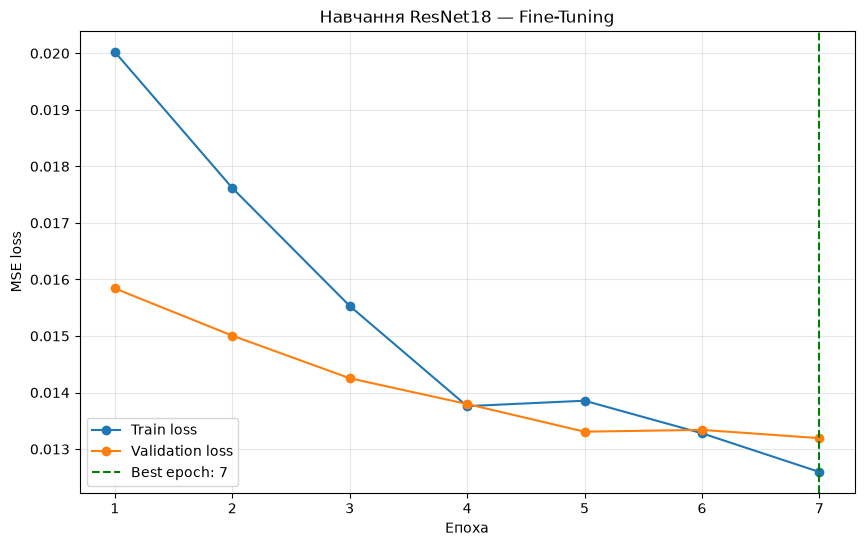

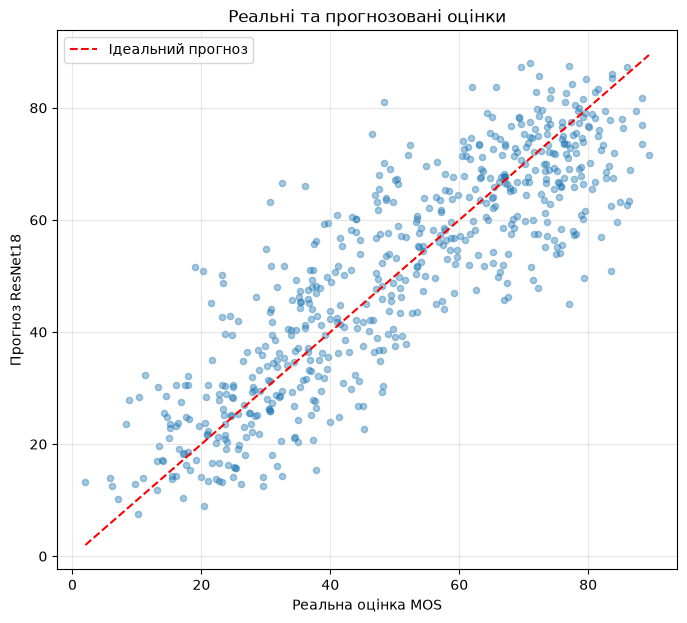

In [37]:
epochs = history_dataframe["epoch"]

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_dataframe["train_loss"],
    marker="o",
    label="Train loss",
)

plt.plot(
    epochs,
    history_dataframe["validation_loss"],
    marker="o",
    label="Validation loss",
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

plt.xlabel("Епоха")
plt.ylabel("MSE loss")
plt.title("Навчання ResNet18 — Fine-Tuning")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(LOSS_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()


true_overall = test_targets[:, 0]
predicted_overall = test_predictions[:, 0]

plt.figure(figsize=(8, 7))

plt.scatter(
    true_overall,
    predicted_overall,
    alpha=0.4,
    s=20,
)

minimum_score = min(
    true_overall.min(),
    predicted_overall.min(),
)

maximum_score = max(
    true_overall.max(),
    predicted_overall.max(),
)

plt.plot(
    [minimum_score, maximum_score],
    [minimum_score, maximum_score],
    color="red",
    linestyle="--",
    label="Ідеальний прогноз",
)

plt.xlabel("Реальна оцінка MOS")
plt.ylabel("Прогноз ResNet18")
plt.title("Реальні та прогнозовані оцінки")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(SCATTER_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

Найгірші прогнози

In [38]:
worst_predictions = (
    predictions_dataframe
    .sort_values(
        "overall_error",
        ascending=False,
    )
    .head(6)
)

display(
    worst_predictions[
        [
            "image_name",
            "true_overall_quality",
            "predicted_overall_quality",
            "overall_error",
        ]
    ]
)

,image_name,true_overall_quality,predicted_overall_quality,overall_error
241,08290.jpg,32.560001,66.584167,34.024166
459,06829.jpg,48.330002,80.986938,32.656937
215,08661.jpg,83.500000,50.935520,32.564480
297,00224.jpg,19.080000,51.545818,32.465820
392,10630.jpg,30.709999,63.175106,32.465107
503,10533.jpg,77.000000,45.061527,31.938473


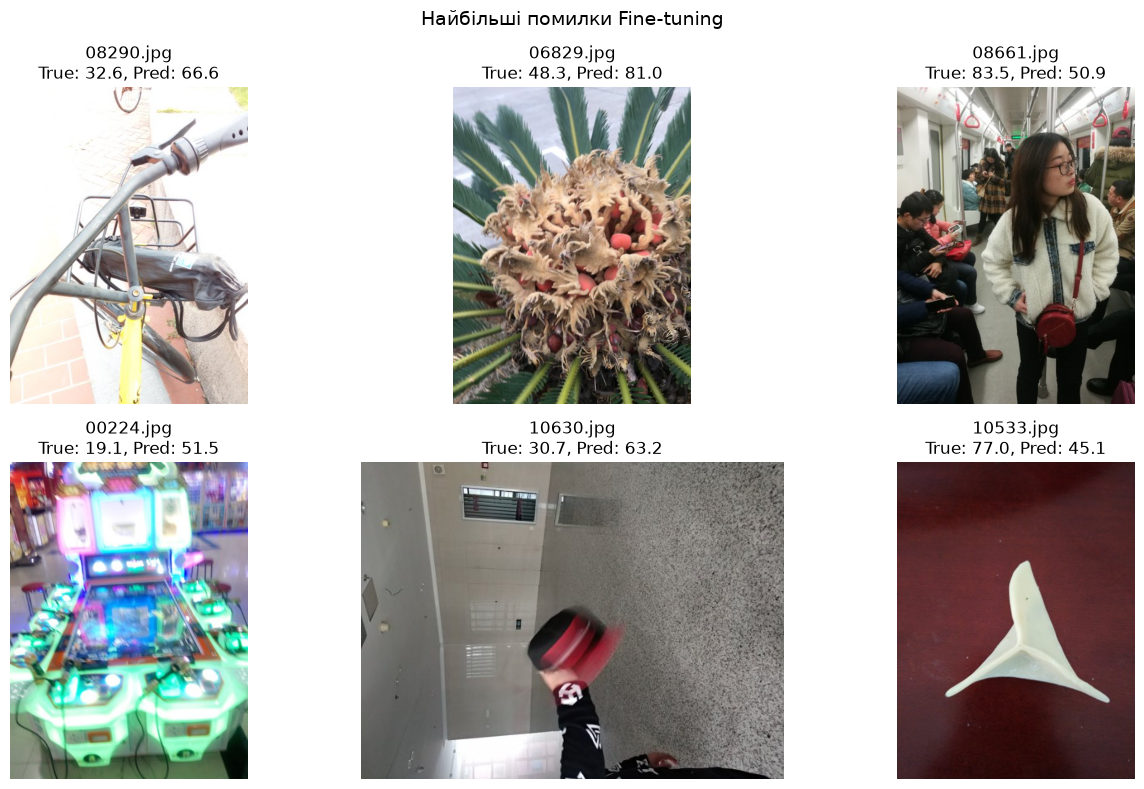

In [39]:
figure, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
)

axes = axes.flatten()

for axis, (_, row) in zip(
    axes,
    worst_predictions.iterrows(),
):
    image_path = (
        IMAGES_DIRECTORY
        / row["image_name"]
    )

    with Image.open(image_path) as image:
        axis.imshow(
            image.convert("RGB")
        )

    axis.set_title(
        f'{row["image_name"]}\n'
        f'True: '
        f'{row["true_overall_quality"]:.1f}, '
        f'Pred: '
        f'{row["predicted_overall_quality"]:.1f}'
    )

    axis.axis("off")

plt.suptitle(
    "Найбільші помилки Fine-tuning",
    fontsize=14,
)

plt.tight_layout()
plt.show()

Порівняння з Feature Extraction

In [40]:
feature_summary_dataframe = pd.read_csv(FEATURE_METRICS_PATH)

In [41]:
comparison_dataframe = pd.concat(
    [feature_summary_dataframe, summary_dataframe],
    ignore_index=True,
)

comparison_dataframe.to_csv(
    COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(comparison_dataframe.round(4))

,model,training_strategy,mae,rmse,plcc,srcc,best_epoch,validation_loss,training_time_seconds,total_parameters,trainable_parameters
0,ResNet18,Feature Extraction,10.6240,13.3424,0.7835,0.7803,4,0.0177,909.8587,11179590,3078
1,ResNet18,Fine-tuning layer4,8.4671,10.7972,0.8643,0.8587,7,0.0132,1196.0306,11179590,8396806
